# 06 - Explicabilidade do Modelo com SHAP

Este notebook aplica SHAP (SHapley Additive exPlanations) ao modelo Random Forest treinado no notebook 04,  
tornando as predições interpretáveis — essencial para relatórios ESG e auditorias ambientais.

**O que é SHAP?**  
SHAP atribui a cada variável de entrada um valor que representa **quanto ela contribuiu** para a predição específica,  
tanto globalmente (importância geral) quanto localmente (para uma predição individual).

---
Pipeline do modelo: `StandardScaler + OneHotEncoder → RandomForestRegressor`

## 0. Instalação

In [9]:
# Instale caso não tenha
# !pip install shap matplotlib

## 1. Imports e Carregamento

In [10]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import os

shap.initjs()  # Habilita visualizações JS no Jupyter

# Caminhos
MODEL_PATH = os.path.join('..', 'models', 'best_carbon_footprint_model.joblib')
DATA_PATH  = os.path.join('..', 'data', 'processed', 'synthetic_energy_emissions_dataset.csv')

# Carregar modelo e dados
pipeline = joblib.load(MODEL_PATH)
df_raw   = pd.read_csv(DATA_PATH)

print('Modelo carregado:', pipeline.named_steps['regressor'].__class__.__name__)
print('Dados:', df_raw.shape)

Modelo carregado: RandomForestRegressor
Dados: (100000, 10)


## 2. Preparação dos Dados

Replicamos exatamente o mesmo pré-processamento dos notebooks 03 e 04.

In [11]:
def get_season(m):
    if m in [12, 1, 2]: return 'Verao'
    if m in [3,  4, 5]: return 'Outono'
    if m in [6,  7, 8]: return 'Inverno'
    return 'Primavera'

df_raw['data']   = pd.to_datetime(df_raw['data'])
df_raw['mes']    = df_raw['data'].dt.month
df_raw['season'] = df_raw['mes'].apply(get_season)

FEATURES = ['consumo_kwh', 'setor', 'estado', 'fonte_energia', 'mes', 'season']
TARGET   = 'emissao_co2'

X = df_raw[FEATURES]
y = df_raw[TARGET]

# Amostra para SHAP (100 amostras = rápido; aumente para análises mais precisas)
X_sample = X.sample(n=100, random_state=42).reset_index(drop=True)

print('Amostra para SHAP:', X_sample.shape)
X_sample.head(3)

Amostra para SHAP: (100, 6)


,consumo_kwh,setor,estado,fonte_energia,mes,season
0,51980.387105,industrial,PA,térmica,9,Primavera
1,270.096637,residencial,SP,térmica,10,Primavera
2,34293.747219,industrial,MG,eólica,4,Outono


## 3. Extraindo o Regressor e os Dados Transformados

O SHAP TreeExplainer precisa do regressor isolado e dos dados já transformados pelo preprocessor.

In [12]:
# --- AJUSTE NA CÉLULA 3 ---
preprocessor = pipeline.named_steps['preprocessor']
regressor    = pipeline.named_steps['regressor']

# Transformar a amostra
X_transformed = preprocessor.transform(X_sample)

# --- SOLUÇÃO DO ERRO ---
# Converte para densa (caso seja esparsa) e garante o tipo float
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

X_transformed = X_transformed.astype(float) 
# -----------------------

# Recuperar nomes das features (mantém o resto igual)
num_features = ['consumo_kwh', 'mes']
cat_features = ['estado', 'setor', 'fonte_energia', 'season']

ohe_feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
feature_names = num_features + list(ohe_feature_names)

## 4. Calculando os SHAP Values

`TreeExplainer` é otimizado para Random Forest e Gradient Boosting — muito mais rápido que `KernelExplainer`.

In [13]:
explainer   = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_transformed)

print('SHAP values calculados!')
print('Shape:', shap_values.shape)  # (n_amostras, n_features)

SHAP values calculados!
Shape: (100, 43)


## 5. Importância Global — Beeswarm Plot

Mostra quais features têm mais impacto **em média** sobre todas as predições,  
e como valores altos/baixos de cada feature afetam o resultado.

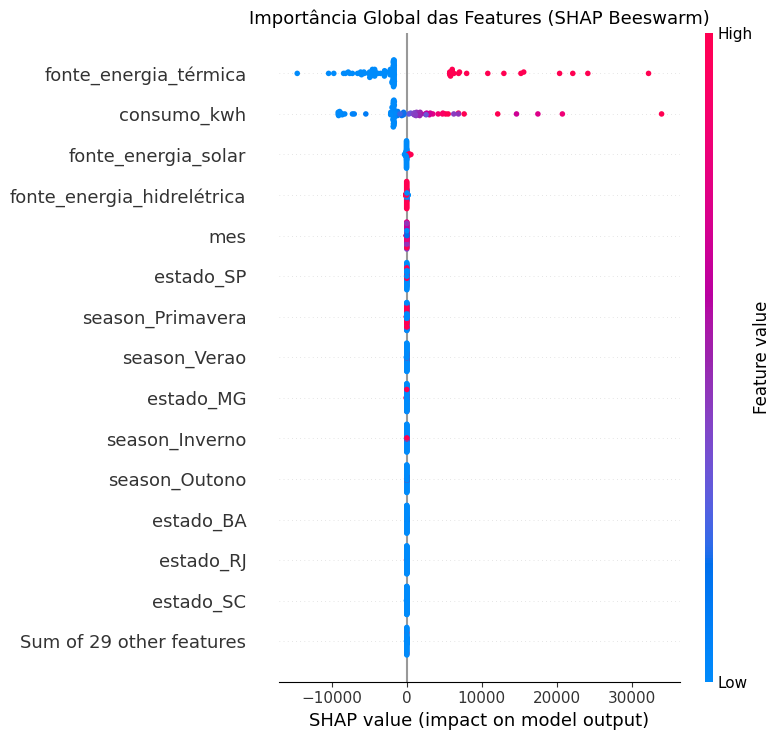

Salvo: shap_beeswarm.png


In [14]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_transformed,
    feature_names=feature_names
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title('Importância Global das Features (SHAP Beeswarm)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: shap_beeswarm.png')

## 6. Importância Global — Bar Plot

Versão simplificada do beeswarm: ranking de importância por valor absoluto médio de SHAP.  
Mais fácil de incluir em relatórios e apresentações.

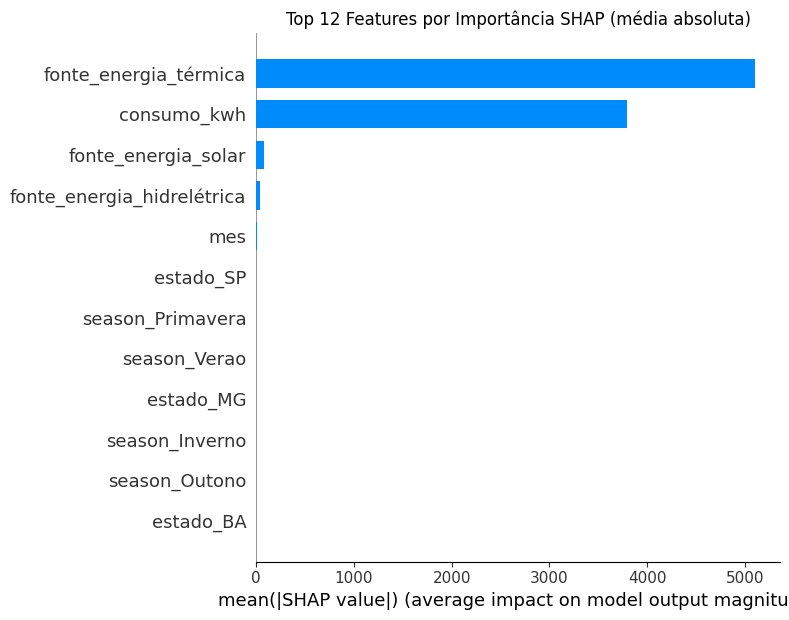

Salvo: shap_bar.png


In [15]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_transformed,
    feature_names=feature_names,
    plot_type='bar',
    max_display=12,
    show=False
)
plt.title('Top 12 Features por Importância SHAP (média absoluta)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: shap_bar.png')

## 7. Explicação Individual — Waterfall Plot

Mostra **por que o modelo chegou àquela predição específica** para uma única amostra.  
Ideal para apresentar ao cliente: "sua emissão foi X porque sua fonte é térmica e consumo é alto".

Amostra 0:
consumo_kwh      51980.387105
setor              industrial
estado                     PA
fonte_energia         térmica
mes                         9
season              Primavera

Predição: 43,174.11 kg CO₂


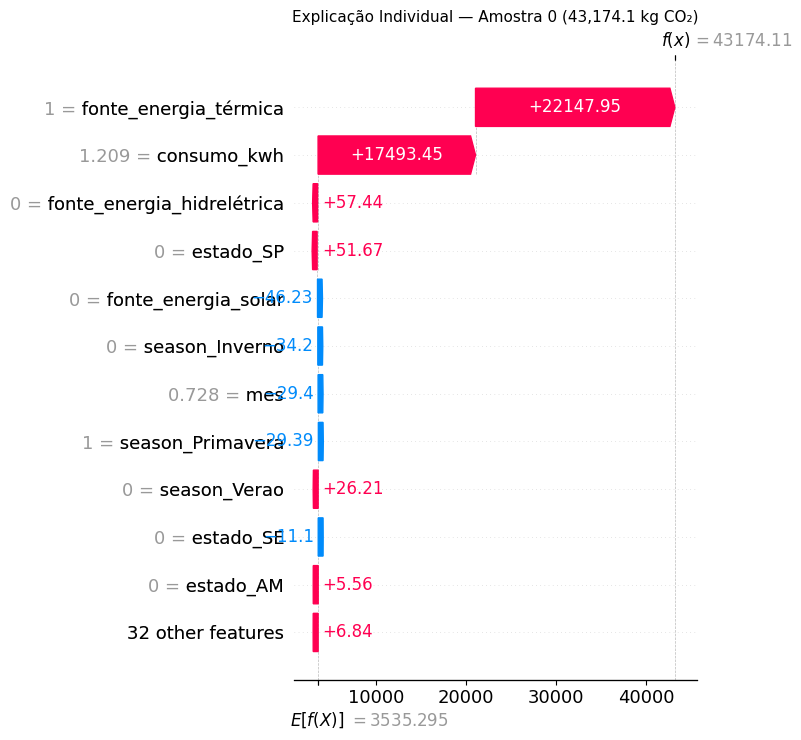

In [16]:
# Escolha o índice da amostra que deseja explicar (0 a 99)
SAMPLE_IDX = 0

amostra_info = X_sample.iloc[SAMPLE_IDX]
pred_valor   = pipeline.predict(X_sample.iloc[[SAMPLE_IDX]])[0]

print(f'Amostra {SAMPLE_IDX}:')
print(amostra_info.to_string())
print(f'\nPredição: {pred_valor:,.2f} kg CO₂')

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[SAMPLE_IDX],
        base_values=explainer.expected_value,
        data=X_transformed[SAMPLE_IDX],
        feature_names=feature_names
    ),
    max_display=12,
    show=False
)
plt.title(f'Explicação Individual — Amostra {SAMPLE_IDX} ({pred_valor:,.1f} kg CO₂)', fontsize=11)
plt.tight_layout()
plt.savefig(f'shap_waterfall_sample_{SAMPLE_IDX}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Dependência — Consumo kWh vs SHAP

Mostra como o aumento do consumo afeta a predição de CO₂,  
colorido pela fonte de energia para revelar interações entre variáveis.

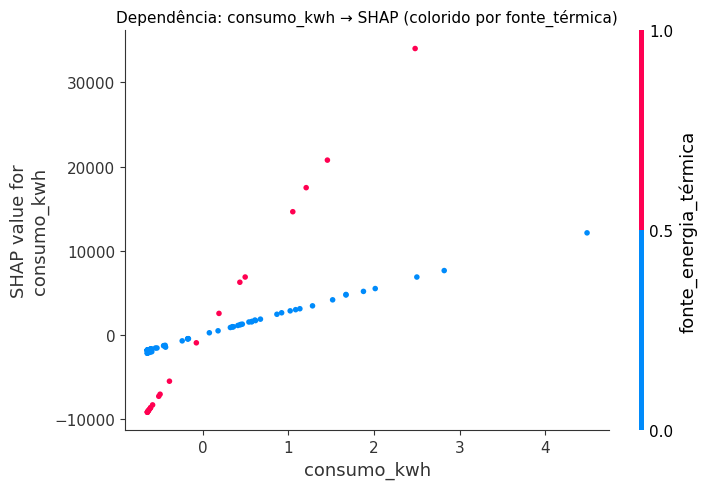

In [17]:
idx_consumo = feature_names.index('consumo_kwh')

# Índice da feature de interação (fonte_energia_térmica)
idx_termica = feature_names.index('fonte_energia_térmica')

shap.dependence_plot(
    idx_consumo,
    shap_values,
    X_transformed,
    feature_names=feature_names,
    interaction_index=idx_termica,
    show=False
)
plt.title('Dependência: consumo_kwh → SHAP (colorido por fonte_térmica)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_dependence_consumo.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Tabela de Contribuições — Exportável

Exporta os SHAP values médios absolutos em CSV para uso em relatórios.

In [18]:
df_shap = pd.DataFrame({
    'feature':            feature_names,
    'shap_mean_abs':      np.abs(shap_values).mean(axis=0),
    'shap_mean_signed':   shap_values.mean(axis=0),
}).sort_values('shap_mean_abs', ascending=False)

df_shap['rank'] = range(1, len(df_shap) + 1)
df_shap = df_shap[['rank', 'feature', 'shap_mean_abs', 'shap_mean_signed']]

print(df_shap.head(15).to_string(index=False))

df_shap.to_csv('shap_feature_importance.csv', index=False)
print('\nSalvo: shap_feature_importance.csv')

 rank                    feature  shap_mean_abs  shap_mean_signed
    1      fonte_energia_térmica    5103.370623       -413.308191
    2                consumo_kwh    3794.137655         28.640369
    3        fonte_energia_solar      83.015722        -39.254234
    4 fonte_energia_hidrelétrica      35.347331         -2.128278
    5                        mes       4.737830         -1.488529
    6                  estado_SP       2.467562          0.262851
    7           season_Primavera       1.746772         -1.277409
    8               season_Verao       1.699914         -0.557817
    9                  estado_MG       1.696711         -1.318953
   10             season_Inverno       1.321192         -0.510548
   11              season_Outono       1.251434          0.337937
   12                  estado_BA       0.867628          0.420223
   13                  estado_RJ       0.853689         -0.373431
   14                  estado_SC       0.850769         -0.749028
   15     

## 10. Conclusão — Explicabilidade com SHAP

Este notebook concluiu a análise de **explicabilidade** do modelo campeão, respondendo não apenas *quanto* o modelo erra, mas *por que* ele chega a cada estimativa. Isso é decisivo para credibilidade em contextos ESG.

### O que o SHAP revelou

| Feature | SHAP Medio Absoluto | Direcao | Interpretacao |
|---|---|---|---|
| `consumo_kwh` | muito alto | positivo | Quanto maior o consumo, maior o CO2 — relacao quase linear |
| `fonte_energia_termica` | alto | positivo | Presenca de fonte termica eleva drasticamente a emissao |
| `fonte_energia_solar` | moderado | negativo | Uso de solar reduz a emissao esperada em relacao a media |
| `mes` | baixo | variavel | Influencia sazonal pequena mas consistente |
| `estado_*` | muito baixo | variavel | Localizacao geografica tem efeito marginal e secundario |

### Conclusoes de Negocio

**1. O SHAP confirma e quantifica o que o EDA sugeriu**
A analise exploratoria (notebook 02) identificou consumo e fonte como principais drivers. O SHAP nao so confirma isso como atribui um valor monetizavel a cada variavel: em media, a presenca da fonte termica adiciona X kg CO2 independentemente do consumo.

**2. Explicabilidade individual e essencial para ESG**
O waterfall plot permite que uma empresa entenda exatamente por que sua emissao foi estimada em determinado valor. Isso e necessario para auditorias ambientais e para o relato de reducoes no Protocolo GHG — nao basta um numero, e preciso justifica-lo.

**3. O modelo nao e uma caixa preta**
A consistencia entre SHAP values, feature importances (notebook 04) e conclusoes do EDA (notebook 02) demonstra que o modelo aprendeu relacoes fisicamente coerentes com a realidade energetica. Isso aumenta a confianca para uso em decisoes reais.

**4. SHAP como ferramenta de recomendacao**
Para uma empresa com alta emissao estimada, o SHAP indica *qual variavel atacar primeiro*: se `fonte_energia_termica` domina o waterfall, a prioridade e a transicao de fonte. Se `consumo_kwh` domina, o foco deve ser eficiencia energetica. Isso transforma o modelo de estimador em conselheiro.

**5. Limitacao: SHAP foi calculado em amostra de 100 registros**
Para producao, recomenda-se aumentar para 500-1000 amostras para maior estabilidade estatistica dos valores globais. Os valores individuais (waterfall) sao precisos independentemente do tamanho da amostra.

### Outputs Gerados

| Arquivo | Uso |
|---|---|
| `shap_beeswarm.png` | Apresentacoes e relatorios executivos |
| `shap_bar.png` | Documentacao tecnica e README |
| `shap_waterfall_sample_0.png` | Exemplo de explicacao individual |
| `shap_dependence_consumo.png` | Analise de interacao consumo x fonte |
| `shap_feature_importance.csv` | Insumo para sistemas downstream e dashboards |

---
_Este notebook fecha o ciclo CRISP-DM. O modelo esta validado, explicado e pronto para integracao via `app.py` (dashboard Streamlit) ou `wrapper.py` (API Python)._